<a href="https://colab.research.google.com/github/paulocesardev8/descomplica-faculdade/blob/main/tecnicas_de_otimiza%C3%A7%C3%A3o_e_processamento_de_imagens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving paulo cesar front end analista de marketing python AI.jpg to paulo cesar front end analista de marketing python AI.jpg


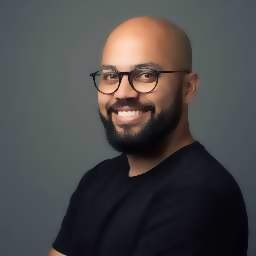

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
Prediction: 4


In [4]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from google.colab import files
from google.colab.patches import cv2_imshow
import io

def compress_image(img):
  img = cv2.resize(img, (256, 256))
  # cv2.imencode returns a tuple: (success, buffer).
  # We only need the buffer (the compressed image data).
  is_success, compressed_img_buffer = cv2.imencode('.jpg', img, [int(cv2.IMWRITE_JPEG_QUALITY), 50])
  if not is_success:
      raise ValueError("Image compression failed.")
  return compressed_img_buffer # This is a numpy array of uint8, representing the compressed image

def denoise_image(image):
    return cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

def create_cnn_model(input_shape):
    model = models.Sequential([
        Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image_stream = io.BytesIO(uploaded[image_path])
file_bytes = np.asarray(bytearray(image_stream.read()), dtype=np.uint8)
image = cv2.imdecode(file_bytes, 1)

try:
  compressed_image_data = compress_image(image)
  # Since compress_image now returns a numpy array of bytes, np.frombuffer is redundant.
  image = cv2.imdecode(compressed_image_data, 1)

  image = denoise_image(image)

  # For CNN model, color image is usually expected (3 channels).
  # If input_shape is (256, 256, 3), convert to RGB or ensure 3 channels.
  # If it should be grayscale, input_shape should be (256, 256, 1).
  # Assuming we keep it color for now, and resize it to 256x256 if not already.
  image = cv2.resize(image, (256, 256)) # Ensure image is 256x256

  # Ensure image has 3 channels if create_cnn_model expects (256, 256, 3)
  if len(image.shape) == 2:
      image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

  image = np.expand_dims(image, axis=0) # Add batch dimension

  model = create_cnn_model((256, 256, 3))
  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

  # cv2_imshow expects an image with shape (H, W, C) or (H, W)
  # The image[0] has shape (256, 256, 3) if converted to color, or (256, 256) if grayscale.
  # cv2.cvtColor(image[0], cv2.COLOR_BGR2RGB) makes sense if image[0] is BGR.
  cv2_imshow(image[0]) # Display the processed image

  prediction = model.predict(image)
  print(f'Prediction: {np.argmax(prediction)}')
except ValueError as e:
  print(e)